# MatchMind - Retrieval Evaluation

This notebook introduces the first quantitative evaluation of semantic retrieval in **MatchMind**.

The previous notebooks established the following pipeline:

```text
StatsBomb events
      |
      v
text representations
      |
      v
chunking strategies
      |
      v
Sentence Transformer embeddings
      |
      v
cosine similarity
      |
      v
Top-K retrieval
```

Notebook 03 showed that chunking has a major effect on document length and retrieval context.

In particular:

```text
Whole possession
    -> preserves full football sequences
    -> 36.99% of documents exceed the 256-token model limit

Fixed token windows
    -> avoid truncation
    -> may create unnatural boundaries

Football-aware chunks
    -> avoid truncation
    -> preserve complete football event descriptions
```

However, qualitative inspection alone is not enough to select a retrieval strategy.

## Objective

The objective of this notebook is to create a small, reproducible retrieval benchmark and measure how well each chunking strategy retrieves the expected football possessions.

We evaluate:

```text
Whole-possession chunks
Fixed token-window chunks
Football-aware chunks
```

while keeping the embedding model unchanged:

```text
sentence-transformers/all-MiniLM-L6-v2
```

This keeps chunking as the main experimental variable.

## Metrics

The notebook introduces:

- `Hit@1`, `Hit@3`, and `Hit@5`;
- `Recall@1`, `Recall@3`, and `Recall@5`;
- Mean Reciprocal Rank (`MRR`);
- the rank of the first relevant possession.

## Important scope

This is a **retrieval evaluation**, not a RAG-generation evaluation.

No generative LLM is used.

The question at this stage is:

> Does the retriever return the football information that should be available to a future LLM?

Generation quality will be studied only after the retrieval component is sufficiently reliable.

## 1. Project setup

This notebook is expected to be located at:

```text
MatchMind/notebooks/04_retrieval_evaluation.ipynb
```

The existing MatchMind modules are reused for data loading and textual representation.

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd()

if (cwd / "src").exists() and (cwd / "data").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "src").exists() and (cwd.parent / "data").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        "Could not locate the MatchMind project root. "
        "Start Jupyter from the MatchMind project or its notebooks directory."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/eldisymeraj/Documents/GitHub/MatchMind


## 2. Imports

The evaluation uses only packages already available in the MatchMind environment.

No new dependency is required.

In [2]:
from collections import defaultdict
import unicodedata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from transformers import AutoTokenizer
from sentence_transformers import SentenceTransformer

from src.data.statsbomb_loader import load_events
from src.text.event_formatter import (
    build_event_documents,
    build_possession_documents,
)

print("Imports loaded successfully.")

/Users/eldisymeraj/Documents/GitHub/MatchMind/matchmind-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports loaded successfully.


## 3. Load the match corpus

The benchmark uses the same 2022 World Cup final data as the previous notebooks.

Penalty-shootout events remain excluded so that retrieval concerns the football match itself, including extra time.

In [3]:
MATCH_ID = 3869685

events = load_events(MATCH_ID)

event_documents = build_event_documents(
    events,
    include_location=False,
    include_shootout=False,
)

possession_documents = build_possession_documents(
    events,
    include_location=False,
    include_shootout=False,
)

print(f"Raw events: {len(events)}")
print(f"Event documents: {len(event_documents)}")
print(f"Possession documents: {len(possession_documents)}")

Raw events: 4407
Event documents: 3252
Possession documents: 246


## 4. Load the embedding model

The model remains fixed across all strategies.

This is essential for a fair comparison:

```text
same match
same textual source
same embedding model
same similarity function

only chunk boundaries change
```

In [4]:
MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
embedding_model = SentenceTransformer(MODEL_NAME)

MAX_SEQUENCE_LENGTH = embedding_model.max_seq_length

print(f"Model: {MODEL_NAME}")
print(f"Maximum sequence length: {MAX_SEQUENCE_LENGTH}")
print(
    "Embedding dimension:",
    embedding_model.get_sentence_embedding_dimension(),
)

Model: sentence-transformers/all-MiniLM-L6-v2
Maximum sequence length: 256
Embedding dimension: 384


# Part I - Rebuild the Chunking Strategies

## 5. Why rebuild the strategies here?

Notebook 03 was exploratory.

For the evaluation, we recreate the same chunk representations in a compact form so that this notebook can be executed independently.

The implementation intentionally mirrors the previous experiment:

```text
Whole possession
Fixed token window: 220 tokens with 30-token overlap
Football-aware: 220-token budget with one-event overlap
```

The parameters are kept unchanged. Changing them now would mix chunk-parameter tuning with retrieval evaluation.

In [5]:
CHUNK_TOKEN_BUDGET = 220
TOKEN_OVERLAP = 30
EVENT_OVERLAP = 1


def count_tokens(text: str) -> int:
    """Count tokenizer tokens without truncating the input text."""

    return len(
        tokenizer(
            text,
            add_special_tokens=True,
            truncation=False,
        )["input_ids"]
    )

## 6. Whole-possession chunks

This is the original baseline.

A complete StatsBomb possession receives one embedding, even when the text exceeds the model's 256-token input limit.

In [6]:
possession_chunks = []

for document in possession_documents:
    chunk = document.copy()
    chunk["chunk_id"] = f"possession_{document['possession_id']}"
    chunk["strategy"] = "whole_possession"
    chunk["token_count"] = count_tokens(document["text"])

    possession_chunks.append(chunk)

print(f"Whole-possession chunks: {len(possession_chunks)}")

Token indices sequence length is longer than the specified maximum sequence length for this model (809 > 512). Running this sequence through the model will result in indexing errors


Whole-possession chunks: 246


## 7. Fixed token-window chunks

This generic RAG baseline uses a 220-token content window with a 30-token overlap.

The split is based on tokenizer positions rather than football-event boundaries.

In [7]:
def build_fixed_token_chunks(
    documents: list[dict],
    max_tokens: int = CHUNK_TOKEN_BUDGET,
    overlap: int = TOKEN_OVERLAP,
) -> list[dict]:
    """Split possession text into overlapping token windows."""

    if max_tokens <= 0:
        raise ValueError("max_tokens must be greater than zero.")

    if overlap < 0 or overlap >= max_tokens:
        raise ValueError(
            "overlap must satisfy 0 <= overlap < max_tokens."
        )

    chunks = []
    step = max_tokens - overlap

    for document in documents:
        token_ids = tokenizer(
            document["text"],
            add_special_tokens=False,
            truncation=False,
        )["input_ids"]

        window_index = 0

        for start in range(0, len(token_ids), step):
            end = min(start + max_tokens, len(token_ids))
            window_ids = token_ids[start:end]

            if not window_ids:
                continue

            text = tokenizer.decode(
                window_ids,
                skip_special_tokens=True,
                clean_up_tokenization_spaces=True,
            )

            chunk = {
                "chunk_id": (
                    f"possession_{document['possession_id']}"
                    f"_window_{window_index}"
                ),
                "strategy": "fixed_token_window",
                "possession_id": document["possession_id"],
                "period": document["period"],
                "possession_team": document["possession_team"],
                "play_pattern": document["play_pattern"],
                "start_minute": document["start_minute"],
                "end_minute": document["end_minute"],
                "players": document["players"],
                "event_types": document["event_types"],
                "text": text,
            }

            chunk["token_count"] = count_tokens(text)
            chunks.append(chunk)

            window_index += 1

            if end == len(token_ids):
                break

    return chunks


fixed_token_chunks = build_fixed_token_chunks(
    possession_documents
)

print(f"Fixed token-window chunks: {len(fixed_token_chunks)}")

Fixed token-window chunks: 433


## 8. Football-aware chunks

The football-aware strategy accumulates complete event descriptions until the next event would exceed the 220-token budget.

One complete event is reused between neighboring chunks to preserve local continuity.

In [8]:
def build_football_aware_chunks(
    event_docs: list[dict],
    max_tokens: int = CHUNK_TOKEN_BUDGET,
    overlap_events: int = EVENT_OVERLAP,
) -> list[dict]:
    """Build token-limited chunks while preserving football-event boundaries."""

    if max_tokens <= 0:
        raise ValueError("max_tokens must be greater than zero.")

    if overlap_events < 0:
        raise ValueError("overlap_events cannot be negative.")

    events_by_possession = defaultdict(list)

    for document in event_docs:
        possession_id = document.get("possession_id")

        if possession_id is not None:
            events_by_possession[possession_id].append(document)

    chunks = []

    for possession_id, possession_events in events_by_possession.items():
        possession_events = sorted(
            possession_events,
            key=lambda document: document.get("index", 0),
        )

        position = 0
        chunk_number = 0

        while position < len(possession_events):
            selected_events = []
            cursor = position

            first_event = possession_events[position]
            possession_team = first_event.get(
                "possession_team",
                "Unknown",
            )

            header = (
                f"Possession {possession_id}. "
                f"{possession_team}."
            )

            while cursor < len(possession_events):
                candidate_events = (
                    selected_events
                    + [possession_events[cursor]]
                )

                candidate_text = (
                    header
                    + "\n"
                    + " ".join(
                        event["text"]
                        for event in candidate_events
                    )
                )

                if count_tokens(candidate_text) <= max_tokens:
                    selected_events = candidate_events
                    cursor += 1
                else:
                    break

            # Defensive fallback for an unexpectedly long single event.
            if not selected_events:
                event = possession_events[position]

                event_ids = tokenizer(
                    event["text"],
                    add_special_tokens=False,
                    truncation=False,
                )["input_ids"]

                safe_ids = event_ids[: max_tokens - 10]

                safe_text = tokenizer.decode(
                    safe_ids,
                    skip_special_tokens=True,
                    clean_up_tokenization_spaces=True,
                )

                selected_events = [
                    {
                        **event,
                        "text": safe_text,
                    }
                ]

                cursor = position + 1

            chunk_text = (
                header
                + "\n"
                + " ".join(
                    event["text"]
                    for event in selected_events
                )
            )

            players = sorted({
                event["player"]
                for event in selected_events
                if event.get("player")
            })

            event_types = sorted({
                event["event_type"]
                for event in selected_events
                if event.get("event_type")
            })

            chunk = {
                "chunk_id": (
                    f"possession_{possession_id}"
                    f"_football_{chunk_number}"
                ),
                "strategy": "football_aware",
                "possession_id": possession_id,
                "period": first_event.get("period"),
                "possession_team": possession_team,
                "start_minute": selected_events[0].get("minute"),
                "end_minute": selected_events[-1].get("minute"),
                "players": players,
                "event_types": event_types,
                "event_count": len(selected_events),
                "text": chunk_text,
            }

            chunk["token_count"] = count_tokens(chunk_text)
            chunks.append(chunk)

            chunk_number += 1

            if cursor >= len(possession_events):
                break

            next_position = (
                cursor
                - min(
                    overlap_events,
                    len(selected_events) - 1,
                )
            )

            position = max(
                position + 1,
                next_position,
            )

    return chunks


football_aware_chunks = build_football_aware_chunks(
    event_documents
)

print(f"Football-aware chunks: {len(football_aware_chunks)}")

Football-aware chunks: 428


## 9. Validate the chunk corpora

Before evaluating retrieval, we verify the number of chunks and maximum token lengths.

The football-aware representation should remain within the selected 220-token budget.

In [9]:
chunk_validation = pd.DataFrame([
    {
        "strategy": "Whole possession",
        "chunks": len(possession_chunks),
        "max_tokens": max(
            chunk["token_count"]
            for chunk in possession_chunks
        ),
    },
    {
        "strategy": "Fixed token window",
        "chunks": len(fixed_token_chunks),
        "max_tokens": max(
            chunk["token_count"]
            for chunk in fixed_token_chunks
        ),
    },
    {
        "strategy": "Football-aware",
        "chunks": len(football_aware_chunks),
        "max_tokens": max(
            chunk["token_count"]
            for chunk in football_aware_chunks
        ),
    },
])

chunk_validation

,strategy,chunks,max_tokens
0,Whole possession,246,1490
1,Fixed token window,433,225
2,Football-aware,428,220


In [10]:
assert max(
    chunk["token_count"]
    for chunk in football_aware_chunks
) <= CHUNK_TOKEN_BUDGET

print("Football-aware token-budget validation passed.")

Football-aware token-budget validation passed.


# Part II - Build an Independent Retrieval Benchmark

## 10. Why do we need ground truth?

A similarity score is not an accuracy score.

For example:

```text
query
    |
    v
retrieved possession
    |
    v
cosine score = 0.62
```

does not tell us whether that possession is actually the correct football context.

Evaluation requires a **ground truth**: a known set of relevant possessions for each query.

## Avoiding circular evaluation

The ground truth in this notebook is derived from the original structured StatsBomb events, not from embedding similarity.

For example:

```text
Query:
"A France attack where Kylian Mbappé takes a shot"

Ground truth:
possessions containing a Shot event by Mbappé for France
```

The embedding model is therefore evaluated against information defined independently from its own scores.

## Benchmark alignment

A benchmark query must describe exactly what its structured rule labels as relevant.

If the query says `before a shot`, the selector must verify event order.

If the query targets an open-play goal, the selector must not silently include a penalty.

This alignment is essential for trustworthy evaluation.

## 11. Helpers for structured ground-truth extraction

Player names may contain accents or full legal names.

For robust matching, names are normalized to lowercase ASCII text before substring comparison.

In [11]:
def normalize_name(value: str | None) -> str:
    """Normalize a name for accent-insensitive substring matching."""

    if not value:
        return ""

    normalized = unicodedata.normalize(
        "NFKD",
        value,
    )

    return "".join(
        character
        for character in normalized
        if not unicodedata.combining(character)
    ).lower()


def nested_name(
    record: dict,
    key: str,
) -> str:
    """Read a nested StatsBomb object name safely."""

    value = record.get(key)

    if isinstance(value, dict):
        return value.get("name", "")

    return ""

## 12. Group raw events by possession

Only periods 1 to 4 are included so that the benchmark remains consistent with the retrieval corpus.

The raw StatsBomb event stream may contain a possession that disappears from the textual corpus because its events are intentionally ignored by the formatter. This is acceptable as long as none of the benchmark's relevant possessions are missing from the retrieval corpus.

In [12]:
events_by_possession = defaultdict(list)

for event in events:
    period = int(event.get("period", 0))
    possession_id = event.get("possession")

    if period == 5 or possession_id is None:
        continue

    events_by_possession[int(possession_id)].append(event)

print(
    "Possessions available in raw match events:",
    len(events_by_possession),
)

Possessions available in raw match events: 247


## 13. Structured event predicate

The helper below identifies football actions directly from StatsBomb fields.

In addition to event type, team, player, outcome, and minute, it can also constrain the shot type.

This is important for distinguishing an open-play goal from a penalty.

In [13]:
def event_matches(
    event: dict,
    *,
    event_type: str | None = None,
    team: str | None = None,
    player_contains: str | None = None,
    shot_outcome: str | None = None,
    shot_type: str | None = None,
    minute_min: int | None = None,
    minute_max: int | None = None,
) -> bool:
    """Check whether a raw StatsBomb event satisfies structured criteria."""

    if (
        event_type is not None
        and nested_name(event, "type") != event_type
    ):
        return False

    if (
        team is not None
        and nested_name(event, "team") != team
    ):
        return False

    if player_contains is not None:
        player_name = normalize_name(
            nested_name(event, "player")
        )

        if normalize_name(player_contains) not in player_name:
            return False

    minute = int(event.get("minute", 0))

    if minute_min is not None and minute < minute_min:
        return False

    if minute_max is not None and minute > minute_max:
        return False

    if shot_outcome is not None or shot_type is not None:
        shot_data = event.get("shot", {})

        if not isinstance(shot_data, dict):
            return False

        if (
            shot_outcome is not None
            and nested_name(shot_data, "outcome") != shot_outcome
        ):
            return False

        if (
            shot_type is not None
            and nested_name(shot_data, "type") != shot_type
        ):
            return False

    return True


def possessions_with_event(**criteria) -> set[int]:
    """Return possession IDs containing at least one matching event."""

    relevant = set()

    for possession_id, possession_events in events_by_possession.items():
        if any(
            event_matches(event, **criteria)
            for event in possession_events
        ):
            relevant.add(possession_id)

    return relevant

## 14. Sequence-level selectors

Some queries describe an ordered sequence rather than the simple presence of two event types.

For example:

```text
pass before shot
```

is stronger than:

```text
pass exists
AND
shot exists
```

The next helper checks that conditions occur in order within the same possession.

In [14]:
def possession_matches_ordered_conditions(
    possession_events: list[dict],
    conditions: list[dict],
) -> bool:
    """Check whether event conditions occur in the requested order."""

    if not conditions:
        return True

    condition_index = 0

    for event in sorted(
        possession_events,
        key=lambda item: item.get("index", 0),
    ):
        if event_matches(
            event,
            **conditions[condition_index],
        ):
            condition_index += 1

            if condition_index == len(conditions):
                return True

    return False


def possessions_with_ordered_conditions(
    conditions: list[dict],
    *,
    possession_team: str | None = None,
) -> set[int]:
    """Return possessions containing an ordered sequence of event conditions."""

    relevant = set()

    for possession_id, possession_events in events_by_possession.items():
        if possession_team is not None:
            possession_teams = {
                nested_name(event, "possession_team")
                for event in possession_events
            }

            if possession_team not in possession_teams:
                continue

        if possession_matches_ordered_conditions(
            possession_events,
            conditions,
        ):
            relevant.add(possession_id)

    return relevant

# Part III - Benchmark Questions

## 15. Define football retrieval queries

The benchmark combines narrow player-specific questions and broader sequence-level questions.

Ground truth is constructed from the structured StatsBomb fields.

Important corrections are applied here:

- the Mbappé equalizer query excludes his earlier penalty by requiring an open-play goal;
- the France shot-possession query says `containing a shot`, matching its actual ground-truth rule;
- the Argentina passing query explicitly requires a `Pass -> Shot` order inside the same possession.

In [15]:
benchmark = [
    {
        "query_id": "q1_mbappe_shot",
        "query": "A France attack where Kylian Mbappé takes a shot",
        "relevant_possessions": possessions_with_event(
            event_type="Shot",
            team="France",
            player_contains="mbappe",
        ),
    },
    {
        "query_id": "q2_messi_shot",
        "query": "An Argentina attack where Lionel Messi takes a shot",
        "relevant_possessions": possessions_with_event(
            event_type="Shot",
            team="Argentina",
            player_contains="messi",
        ),
    },
    {
        "query_id": "q3_di_maria_goal",
        "query": (
            "Argentina creates the move that leads to "
            "Ángel Di María scoring before half-time"
        ),
        "relevant_possessions": possessions_with_event(
            event_type="Shot",
            team="Argentina",
            player_contains="di maria",
            shot_outcome="Goal",
            minute_min=30,
            minute_max=45,
        ),
    },
    {
        "query_id": "q4_mbappe_equalizer",
        "query": (
            "France creates the open-play attack that ends "
            "with Mbappé scoring the equalizer around the 81st minute"
        ),
        "relevant_possessions": possessions_with_event(
            event_type="Shot",
            team="France",
            player_contains="mbappe",
            shot_outcome="Goal",
            shot_type="Open Play",
            minute_min=80,
            minute_max=82,
        ),
    },
    {
        "query_id": "q5_messi_extra_time_goal",
        "query": (
            "Argentina creates the extra-time attack "
            "that ends with Messi scoring"
        ),
        "relevant_possessions": possessions_with_event(
            event_type="Shot",
            team="Argentina",
            player_contains="messi",
            shot_outcome="Goal",
            minute_min=100,
        ),
    },
    {
        "query_id": "q6_kolo_muani_late_chance",
        "query": (
            "France gets a late shooting chance "
            "through Randal Kolo Muani"
        ),
        "relevant_possessions": possessions_with_event(
            event_type="Shot",
            team="France",
            player_contains="kolo muani",
            minute_min=100,
        ),
    },
    {
        "query_id": "q7_lautaro_extra_time",
        "query": (
            "Argentina creates an extra-time shooting "
            "chance for Lautaro Martínez"
        ),
        "relevant_possessions": possessions_with_event(
            event_type="Shot",
            team="Argentina",
            player_contains="lautaro",
            minute_min=90,
        ),
    },
    {
        "query_id": "q8_france_shot_possession",
        "query": (
            "A France attacking possession containing a shot"
        ),
        "relevant_possessions": possessions_with_event(
            event_type="Shot",
            team="France",
        ),
    },
    {
        "query_id": "q9_argentina_passes_before_shot",
        "query": (
            "Argentina builds an attacking sequence "
            "with a pass before taking a shot"
        ),
        "relevant_possessions": possessions_with_ordered_conditions(
            [
                {
                    "event_type": "Pass",
                    "team": "Argentina",
                },
                {
                    "event_type": "Shot",
                    "team": "Argentina",
                },
            ],
            possession_team="Argentina",
        ),
    },
]

print(f"Benchmark queries: {len(benchmark)}")

Benchmark queries: 9


## 16. Inspect and validate the benchmark

Every query must have at least one known relevant possession.

The table below is important: it exposes the exact ground-truth possession IDs used by the evaluation instead of hiding them inside the metric code.

In [16]:
benchmark_summary = pd.DataFrame([
    {
        "query_id": item["query_id"],
        "query": item["query"],
        "relevant_count": len(
            item["relevant_possessions"]
        ),
        "relevant_possessions": sorted(
            item["relevant_possessions"]
        ),
    }
    for item in benchmark
])

benchmark_summary

,query_id,query,relevant_count,relevant_possessions
0,q1_mbappe_shot,A France attack where Kylian Mbappé takes a shot,6,"[138, 163, 165, 183, 237, 238]"
1,q2_messi_shot,An Argentina attack where Lionel Messi takes a...,5,"[32, 116, 191, 226, 228]"
2,q3_di_maria_goal,Argentina creates the move that leads to Ángel...,1,[52]
3,q4_mbappe_equalizer,France creates the open-play attack that ends ...,1,[165]
4,q5_messi_extra_time_goal,Argentina creates the extra-time attack that e...,1,[228]
5,q6_kolo_muani_late_chance,France gets a late shooting chance through Ran...,1,[245]
6,q7_lautaro_extra_time,Argentina creates an extra-time shooting chanc...,4,"[218, 221, 228, 246]"
7,q8_france_shot_possession,A France attacking possession containing a shot,10,"[131, 138, 163, 165, 183, 184, 213, 237, 238, ..."
8,q9_argentina_passes_before_shot,Argentina builds an attacking sequence with a ...,17,"[14, 18, 27, 46, 52, 86, 107, 116, 139, 167, 1..."


In [17]:
empty_queries = benchmark_summary[
    benchmark_summary["relevant_count"] == 0
]

assert empty_queries.empty, (
    "At least one benchmark query has no relevant possession. "
    "Inspect benchmark_summary and adjust the corresponding selector."
)

print("Non-empty benchmark validation passed.")

Non-empty benchmark validation passed.


## 17. Verify that every relevant possession is retrievable

The structured raw event stream and the textual retrieval corpus do not necessarily contain the exact same number of possessions.

For example, a possession containing only event types ignored by the text formatter may disappear from the retrieval corpus.

That difference is acceptable only if it does not affect the benchmark.

A relevant possession must never be absent from the retrieval corpus, otherwise the evaluator would penalize the retriever for an impossible task.

In [18]:
retrievable_possessions = {
    int(chunk["possession_id"])
    for chunk in possession_chunks
}

benchmark_relevant_possessions = set().union(
    *[
        item["relevant_possessions"]
        for item in benchmark
    ]
)

missing_relevant_possessions = (
    benchmark_relevant_possessions
    - retrievable_possessions
)

print(
    "Retrievable textual possessions:",
    len(retrievable_possessions),
)

print(
    "Raw event possessions:",
    len(events_by_possession),
)

print(
    "Relevant possessions absent from retrieval corpus:",
    sorted(missing_relevant_possessions),
)

assert not missing_relevant_possessions, (
    "At least one benchmark ground-truth possession cannot be retrieved "
    "because it is absent from the textual corpus."
)

print("Retrievability validation passed.")

Retrievable textual possessions: 246
Raw event possessions: 247
Relevant possessions absent from retrieval corpus: []
Retrievability validation passed.


### Why relevant counts differ

Some questions target one very specific football moment, while others describe a broader class of situations.

For example:

```text
"Di María scoring before half-time"
```

should identify a very small set of relevant possessions.

By contrast:

```text
"A France attacking possession containing a shot"
```

can have many relevant possessions.

This distinction is exactly why both `Hit@K` and `Recall@K` are useful.

# Part IV - Embed the Retrieval Corpora

## 18. Encode every strategy

All chunk embeddings are normalized.

With normalized embeddings, cosine similarity can be computed efficiently as a dot product.

In [19]:
def encode_chunks(
    chunks: list[dict],
) -> np.ndarray:
    """Encode chunk text into normalized sentence embeddings."""

    return embedding_model.encode(
        [
            chunk["text"]
            for chunk in chunks
        ],
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=True,
        batch_size=64,
    )


possession_embeddings = encode_chunks(
    possession_chunks
)

fixed_token_embeddings = encode_chunks(
    fixed_token_chunks
)

football_aware_embeddings = encode_chunks(
    football_aware_chunks
)

print("Whole possession:", possession_embeddings.shape)
print("Fixed token window:", fixed_token_embeddings.shape)
print("Football-aware:", football_aware_embeddings.shape)

Batches: 100%|██████████| 7/7 [00:33<00:00,  4.81s/it]

Whole possession: (246, 384)
Fixed token window: (433, 384)
Football-aware: (428, 384)


# Part V - Ranking and Fair Comparison

## 19. Rank chunks for a query

The retriever first ranks individual chunks by cosine similarity.

In [20]:
def rank_chunks(
    query: str,
    chunks: list[dict],
    embeddings: np.ndarray,
) -> list[dict]:
    """Rank every chunk by semantic similarity to a query."""

    query_embedding = embedding_model.encode(
        query,
        convert_to_numpy=True,
        normalize_embeddings=True,
    )

    scores = embeddings @ query_embedding
    order = np.argsort(scores)[::-1]

    ranked = []

    for chunk_rank, index in enumerate(
        order,
        start=1,
    ):
        chunk = chunks[int(index)]

        ranked.append({
            "chunk_rank": chunk_rank,
            "score": float(scores[index]),
            "chunk_id": chunk["chunk_id"],
            "possession_id": int(
                chunk["possession_id"]
            ),
            "text": chunk["text"],
        })

    return ranked

## 20. Why possession-level deduplication is necessary

Whole-possession retrieval has exactly one chunk per possession.

Fixed-window and football-aware strategies can produce several chunks from the same possession.

Without deduplication, a Top-5 list could contain:

```text
rank 1 -> possession 50, chunk 1
rank 2 -> possession 50, chunk 2
rank 3 -> possession 50, chunk 3
rank 4 -> possession 131, chunk 1
rank 5 -> possession 42, chunk 1
```

If the benchmark ground truth is defined at the possession level, counting all three possession-50 chunks as different retrieved football situations would make the comparison unfair.

For this first benchmark, each possession is therefore counted only once, at the rank of its highest-scoring chunk.

This evaluates:

> How quickly does the strategy surface the correct football possession?

It does **not yet** evaluate whether the exact best subchunk inside that possession was retrieved.

In [21]:
def deduplicate_by_possession(
    ranked_chunks: list[dict],
) -> list[dict]:
    """Keep only the highest-ranked chunk for each possession."""

    seen = set()
    ranked_possessions = []

    for result in ranked_chunks:
        possession_id = result[
            "possession_id"
        ]

        if possession_id in seen:
            continue

        seen.add(possession_id)

        ranked_possessions.append({
            **result,
            "possession_rank": (
                len(ranked_possessions) + 1
            ),
        })

    return ranked_possessions

# Part VI - Retrieval Metrics

## 21. Hit@K

`Hit@K` answers:

> Is at least one relevant possession present in the first K unique retrieved possessions?

For one query:

```text
Hit@K = 1  if at least one relevant result appears in Top-K
Hit@K = 0  otherwise
```

It is useful when finding at least one correct context is enough to help a future RAG system.

## 22. Recall@K

`Recall@K` answers:

> What fraction of all known relevant possessions was retrieved in the first K results?

```text
Recall@K =
number of relevant possessions retrieved in Top-K
-------------------------------------------------
total number of relevant possessions
```

If a query has only one relevant possession, Recall@K behaves like Hit@K.

If a query has several relevant possessions, Recall@K measures retrieval coverage.

## 23. Reciprocal Rank and MRR

For a single query, reciprocal rank uses the position of the first relevant result:

```text
first relevant rank = 1 -> RR = 1.00
first relevant rank = 2 -> RR = 0.50
first relevant rank = 4 -> RR = 0.25
```

Mean Reciprocal Rank (`MRR`) is the average reciprocal rank across benchmark queries.

MRR rewards systems that place a relevant result near the top of the ranking.

In [22]:
def evaluate_ranking(
    ranked_possessions: list[dict],
    relevant_possessions: set[int],
    ks: tuple[int, ...] = (1, 3, 5),
) -> dict:
    """Compute Hit@K, Recall@K and reciprocal rank for one query."""

    ranked_ids = [
        result["possession_id"]
        for result in ranked_possessions
    ]

    metrics = {}

    for k in ks:
        top_k = set(ranked_ids[:k])

        retrieved_relevant = (
            top_k
            & relevant_possessions
        )

        metrics[f"hit@{k}"] = int(
            len(retrieved_relevant) > 0
        )

        metrics[f"recall@{k}"] = (
            len(retrieved_relevant)
            / len(relevant_possessions)
        )

    first_relevant_rank = None

    for rank, possession_id in enumerate(
        ranked_ids,
        start=1,
    ):
        if possession_id in relevant_possessions:
            first_relevant_rank = rank
            break

    metrics["first_relevant_rank"] = (
        first_relevant_rank
    )

    metrics["reciprocal_rank"] = (
        0.0
        if first_relevant_rank is None
        else 1.0 / first_relevant_rank
    )

    return metrics

# Part VII - Run the Benchmark

## 24. Evaluate one strategy

The helper below:

1. embeds the query;
2. ranks all chunks;
3. deduplicates results by possession;
4. computes retrieval metrics;
5. keeps the Top-5 possession IDs for inspection.

In [23]:
def evaluate_strategy(
    strategy_name: str,
    chunks: list[dict],
    embeddings: np.ndarray,
    benchmark_items: list[dict],
) -> pd.DataFrame:
    """Evaluate one chunking strategy across the complete benchmark."""

    rows = []

    for item in benchmark_items:
        ranked_chunks = rank_chunks(
            query=item["query"],
            chunks=chunks,
            embeddings=embeddings,
        )

        ranked_possessions = (
            deduplicate_by_possession(
                ranked_chunks
            )
        )

        metrics = evaluate_ranking(
            ranked_possessions,
            item["relevant_possessions"],
        )

        rows.append({
            "strategy": strategy_name,
            "query_id": item["query_id"],
            "query": item["query"],
            "relevant_count": len(
                item["relevant_possessions"]
            ),
            **metrics,
            "top5_possessions": [
                result["possession_id"]
                for result
                in ranked_possessions[:5]
            ],
        })

    return pd.DataFrame(rows)

## 25. Evaluate all three strategies

In [24]:
strategy_inputs = {
    "Whole possession": (
        possession_chunks,
        possession_embeddings,
    ),
    "Fixed token window": (
        fixed_token_chunks,
        fixed_token_embeddings,
    ),
    "Football-aware": (
        football_aware_chunks,
        football_aware_embeddings,
    ),
}

evaluation_frames = []

for strategy_name, (
    chunks,
    embeddings,
) in strategy_inputs.items():

    evaluation_frames.append(
        evaluate_strategy(
            strategy_name,
            chunks,
            embeddings,
            benchmark,
        )
    )

evaluation_results = pd.concat(
    evaluation_frames,
    ignore_index=True,
)

evaluation_results.head()

,strategy,query_id,query,relevant_count,hit@1,recall@1,hit@3,recall@3,hit@5,recall@5,first_relevant_rank,reciprocal_rank,top5_possessions
0,Whole possession,q1_mbappe_shot,A France attack where Kylian Mbappé takes a shot,6,1,0.166667,1,0.333333,1,0.5,1,1.000000,"[183, 187, 237, 173, 163]"
1,Whole possession,q2_messi_shot,An Argentina attack where Lionel Messi takes a...,5,1,0.200000,1,0.400000,1,0.4,1,1.000000,"[226, 27, 116, 240, 219]"
2,Whole possession,q3_di_maria_goal,Argentina creates the move that leads to Ángel...,1,0,0.000000,0,0.000000,0,0.0,7,0.142857,"[35, 77, 80, 107, 39]"
3,Whole possession,q4_mbappe_equalizer,France creates the open-play attack that ends ...,1,0,0.000000,0,0.000000,0,0.0,110,0.009091,"[180, 108, 163, 238, 113]"
4,Whole possession,q5_messi_extra_time_goal,Argentina creates the extra-time attack that e...,1,0,0.000000,0,0.000000,0,0.0,27,0.037037,"[27, 10, 32, 19, 18]"


## 26. Query-level results

This table makes it possible to inspect where each strategy succeeds or fails.

A low aggregate metric can sometimes be explained by only a few particularly difficult queries.

In [25]:
evaluation_results[
    [
        "strategy",
        "query_id",
        "relevant_count",
        "hit@1",
        "hit@3",
        "hit@5",
        "recall@1",
        "recall@3",
        "recall@5",
        "first_relevant_rank",
        "reciprocal_rank",
    ]
].sort_values(
    [
        "query_id",
        "strategy",
    ]
)

,strategy,query_id,relevant_count,hit@1,hit@3,hit@5,recall@1,recall@3,recall@5,first_relevant_rank,reciprocal_rank
9,Fixed token window,q1_mbappe_shot,6,1,1,1,0.166667,0.333333,0.500000,1,1.000000
18,Football-aware,q1_mbappe_shot,6,1,1,1,0.166667,0.500000,0.666667,1,1.000000
0,Whole possession,q1_mbappe_shot,6,1,1,1,0.166667,0.333333,0.500000,1,1.000000
10,Fixed token window,q2_messi_shot,5,1,1,1,0.200000,0.400000,0.600000,1,1.000000
19,Football-aware,q2_messi_shot,5,0,1,1,0.000000,0.400000,0.600000,2,0.500000
1,Whole possession,q2_messi_shot,5,1,1,1,0.200000,0.400000,0.400000,1,1.000000
11,Fixed token window,q3_di_maria_goal,1,0,0,0,0.000000,0.000000,0.000000,10,0.100000
20,Football-aware,q3_di_maria_goal,1,0,0,0,0.000000,0.000000,0.000000,16,0.062500
2,Whole possession,q3_di_maria_goal,1,0,0,0,0.000000,0.000000,0.000000,7,0.142857
12,Fixed token window,q4_mbappe_equalizer,1,0,0,0,0.000000,0.000000,0.000000,11,0.090909


# Part VIII - Aggregate Metrics

## 27. Aggregate over all benchmark queries

For the benchmark as a whole:

```text
mean Hit@K
```

is the fraction of queries for which at least one relevant possession was retrieved within the first K positions.

```text
mean Recall@K
```

is the average fraction of relevant possessions recovered for each query.

```text
MRR
```

is the mean reciprocal rank of the first relevant possession.

In [26]:
aggregate_metrics = (
    evaluation_results
    .groupby("strategy")
    .agg(
        hit_at_1=("hit@1", "mean"),
        hit_at_3=("hit@3", "mean"),
        hit_at_5=("hit@5", "mean"),
        recall_at_1=("recall@1", "mean"),
        recall_at_3=("recall@3", "mean"),
        recall_at_5=("recall@5", "mean"),
        mrr=("reciprocal_rank", "mean"),
        mean_first_relevant_rank=(
            "first_relevant_rank",
            "mean",
        ),
    )
    .sort_values(
        "mrr",
        ascending=False,
    )
)

aggregate_metrics.round(3)

,hit_at_1,hit_at_3,hit_at_5,recall_at_1,recall_at_3,recall_at_5,mrr,mean_first_relevant_rank
strategy,,,,,,,,
Fixed token window,0.444,0.556,0.667,0.075,0.296,0.360,0.551,9.667
Whole possession,0.444,0.556,0.667,0.075,0.268,0.304,0.549,17.111
Football-aware,0.333,0.667,0.778,0.053,0.397,0.501,0.519,8.667


## 28. Visualize the main retrieval metrics

The chart provides a compact comparison of the three chunking strategies.

It should be interpreted together with the query-level results rather than as a standalone final verdict.

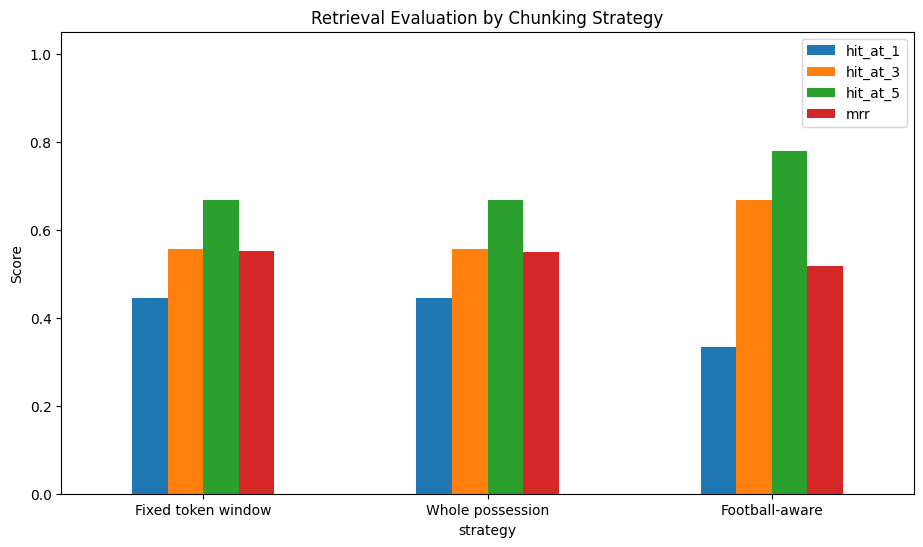

In [27]:
plot_metrics = aggregate_metrics[
    [
        "hit_at_1",
        "hit_at_3",
        "hit_at_5",
        "mrr",
    ]
]

plot_metrics.plot(
    kind="bar",
    figsize=(11, 6),
)

plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Retrieval Evaluation by Chunking Strategy")
plt.xticks(rotation=0)
plt.legend()
plt.show()

# Part IX - Inspect Retrieval Failures

## 29. Find queries missed in the Top-5

Aggregate scores do not explain why retrieval failed.

We therefore identify cases where no relevant possession appeared in the first five unique retrieved possessions.

In [28]:
top5_failures = evaluation_results[
    evaluation_results["hit@5"] == 0
][
    [
        "strategy",
        "query_id",
        "query",
        "relevant_count",
        "first_relevant_rank",
        "top5_possessions",
    ]
]

top5_failures

,strategy,query_id,query,relevant_count,first_relevant_rank,top5_possessions
2,Whole possession,q3_di_maria_goal,Argentina creates the move that leads to Ángel...,1,7,"[35, 77, 80, 107, 39]"
3,Whole possession,q4_mbappe_equalizer,France creates the open-play attack that ends ...,1,110,"[180, 108, 163, 238, 113]"
4,Whole possession,q5_messi_extra_time_goal,Argentina creates the extra-time attack that e...,1,27,"[27, 10, 32, 19, 18]"
11,Fixed token window,q3_di_maria_goal,Argentina creates the move that leads to Ángel...,1,10,"[35, 25, 39, 77, 80]"
12,Fixed token window,q4_mbappe_equalizer,France creates the open-play attack that ends ...,1,11,"[180, 136, 108, 163, 238]"
13,Fixed token window,q5_messi_extra_time_goal,Argentina creates the extra-time attack that e...,1,56,"[27, 18, 10, 32, 19]"
20,Football-aware,q3_di_maria_goal,Argentina creates the move that leads to Ángel...,1,16,"[44, 23, 18, 25, 35]"
22,Football-aware,q5_messi_extra_time_goal,Argentina creates the extra-time attack that e...,1,48,"[27, 19, 18, 41, 244]"


## 30. Inspect one query across all strategies

Choose a benchmark query below and compare the actual retrieved text.

This provides the qualitative context needed to interpret the numerical metrics.

In [29]:
INSPECTION_QUERY_ID = benchmark[0]["query_id"]

selected_item = next(
    item
    for item in benchmark
    if item["query_id"] == INSPECTION_QUERY_ID
)

print("Query:")
print(selected_item["query"])

print("\nRelevant possessions:")
print(
    sorted(
        selected_item["relevant_possessions"]
    )
)

Query:
A France attack where Kylian Mbappé takes a shot

Relevant possessions:
[138, 163, 165, 183, 237, 238]


In [30]:
for strategy_name, (
    chunks,
    embeddings,
) in strategy_inputs.items():

    ranked_chunks = rank_chunks(
        query=selected_item["query"],
        chunks=chunks,
        embeddings=embeddings,
    )

    ranked_possessions = (
        deduplicate_by_possession(
            ranked_chunks
        )
    )

    print("\n" + "=" * 100)
    print(strategy_name.upper())
    print("=" * 100)

    for result in ranked_possessions[:5]:
        relevant = (
            result["possession_id"]
            in selected_item[
                "relevant_possessions"
            ]
        )

        print(
            f"Rank {result['possession_rank']} | "
            f"score={result['score']:.4f} | "
            f"possession={result['possession_id']} | "
            f"relevant={relevant}"
        )

        print("-" * 100)
        print(result["text"])
        print()


WHOLE POSSESSION
Rank 1 | score=0.6556 | possession=183 | relevant=True
----------------------------------------------------------------------------------------------------
Possession 183. France. Play pattern: From Counter. From 92:51 to 92:58.
92:51 - France: Eduardo Camavinga is involved in a duel. 92:52 - France: Kylian Mbappé Lottin recovers the ball. 92:52 - France: Kylian Mbappé Lottin carries the ball. 92:56 - Argentina: Enzo Fernandez applies pressure. 92:57 - France: Kylian Mbappé Lottin takes a shot with an xG of 0.032. The shot outcome is Blocked. 92:58 - Argentina: Nicolás Hernán Otamendi performs a Block event. 92:58 - Argentina: Damián Emiliano Martínez performs a goalkeeper action: Shot Faced.

Rank 2 | score=0.5959 | possession=187 | relevant=False
----------------------------------------------------------------------------------------------------
Possession 187. France. Play pattern: Regular Play. From 94:59 to 95:12.
94:59 - France: Eduardo Camavinga completes a pas

# Part X - Retrieval Diversity

## 31. Multiple chunks can compete for the same possession

Although possession-level deduplication makes the benchmark fair, a real RAG system normally retrieves chunks directly.

If several Top-K chunks originate from the same possession, the final context may contain redundant information.

We therefore measure the number of unique possessions represented in the raw Top-5 chunk results.

A value of 5 means every chunk comes from a different possession.

A lower value indicates duplication.

In [31]:
def top_k_unique_possessions(
    query: str,
    chunks: list[dict],
    embeddings: np.ndarray,
    top_k: int = 5,
) -> int:
    """Count unique possession IDs among raw Top-K chunk results."""

    ranked = rank_chunks(
        query=query,
        chunks=chunks,
        embeddings=embeddings,
    )

    return len({
        result["possession_id"]
        for result in ranked[:top_k]
    })

In [32]:
diversity_rows = []

for item in benchmark:
    for strategy_name, (
        chunks,
        embeddings,
    ) in strategy_inputs.items():

        diversity_rows.append({
            "query_id": item["query_id"],
            "strategy": strategy_name,
            "unique_possessions_in_top5": (
                top_k_unique_possessions(
                    query=item["query"],
                    chunks=chunks,
                    embeddings=embeddings,
                    top_k=5,
                )
            ),
        })

diversity_results = pd.DataFrame(
    diversity_rows
)

diversity_results.groupby(
    "strategy"
)["unique_possessions_in_top5"].mean().sort_values(
    ascending=False
)

strategy
Fixed token window    5.0
Football-aware        5.0
Whole possession      5.0
Name: unique_possessions_in_top5, dtype: float64

This diagnostic does not determine retrieval quality by itself.

A strategy can return several useful neighboring chunks from the same possession, but excessive duplication may reduce the amount of distinct evidence available to a future RAG prompt.

# Part XI - Interpretation and Limitations

## 32. What the metrics tell us

The metrics capture different retrieval properties.

### Hit@K

Useful when the main objective is to retrieve at least one useful context.

### Recall@K

Useful when several possessions are known to be relevant and the system should recover more than one of them.

### MRR

Useful when the first relevant result should appear as high as possible in the ranking.

No single metric completely describes retrieval quality.

The query-level results and retrieved text should always be inspected alongside aggregate scores.

## 33. Important limitations of this benchmark

This evaluation is a first controlled experiment, not a final production benchmark.

### Small benchmark

The benchmark contains only a limited number of questions from one football match.

### Structured rule-based ground truth

Relevant possessions are derived from StatsBomb event criteria.

This provides reproducibility, but it does not fully capture every possession that a human analyst might consider semantically useful.

### Query-label alignment

The benchmark now explicitly aligns natural-language queries with their structured labeling rules.

However, future benchmark expansion should continue to verify this alignment manually.

### Possession-level relevance

For fair comparison, relevance is currently defined at the possession level.

A future evaluation should also consider whether the retrieved **subchunk** contains the exact evidence needed to answer the question.

### Temporal language is not explicit in the documents

Queries such as:

```text
before half-time
extra-time attack
```

express football phases semantically.

The current textual documents primarily encode timestamps rather than explicit phrases such as:

```text
first half
second half
extra time
```

A failure on those queries may therefore indicate a text-representation limitation rather than only a chunking limitation.

### One embedding model

Only `all-MiniLM-L6-v2` is evaluated.

This is intentional because the current experiment focuses on chunking, not model selection.

### No reranker

The ranking is based only on dense embedding similarity.

A later retrieval pipeline may improve ordering using a reranker or hybrid dense-sparse retrieval.

# Final Conclusion

This notebook converts MatchMind retrieval analysis from qualitative inspection into a reproducible quantitative experiment.

The evaluation pipeline is now:

```text
natural-language query
        |
        v
query embedding
        |
        v
chunk similarity ranking
        |
        v
possession-level deduplication
        |
        v
comparison with structured ground truth
        |
        v
Hit@K / Recall@K / MRR
```

The corrected benchmark also introduces several safeguards:

```text
query wording
must match
ground-truth logic

relevant possessions
must exist in
the retrieval corpus

ordered football sequences
must be labeled
with ordered event criteria
```

The aggregate metric table should be used to identify promising strategies, but the result should not yet be treated as a universal conclusion because the benchmark is limited to one match and a small number of queries.

The most important outcome of this stage is methodological:

```text
retrieval choices
must be measured
rather than assumed
```

## Next step

After inspecting the corrected benchmark results, MatchMind can decide whether:

```text
1. the football-aware strategy is sufficiently strong;
2. the token budget or overlap should be tuned;
3. the text representation needs richer temporal metadata;
4. additional benchmark questions are needed.
```

Once the retrieval representation is validated, the stable chunking and embedding logic can be moved into reusable `src/` modules.

Only after that should MatchMind introduce a persistent vector database such as Qdrant.